<a href="https://colab.research.google.com/github/echetan-max/-Bitcoin-Market-Sentiment/blob/main/BTDC_FEARVSGREED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [11]:
# 1. Load and Standardize Data
trader_url = "https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"
sentiment_url = "https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"

trades = pd.read_csv(trader_url)
sentiment = pd.read_csv(sentiment_url)

# Standardize column names immediately
trades.columns = trades.columns.str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.lower().str.replace(" ", "_")

# Convert timestamps to datetime
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Create standardized merge keys (date only)
trades['date_for_merge'] = trades['timestamp_ist'].dt.date
sentiment['date_for_merge'] = sentiment['date'].dt.date

print("Data loaded and column names standardized.")

Data loaded and column names standardized.


In [12]:
# 2. Merge and Feature Engineering
# Merge sentiment onto trades
df = pd.merge(trades, sentiment[['date_for_merge', 'classification']], on='date_for_merge', how='left')

# Drop rows with missing critical trade data
df = df.dropna(subset=['execution_price', 'size_tokens', 'size_usd'])

# Calculate metrics using correct standardized names
df['notional'] = df['execution_price'] * df['size_tokens']
df['is_profit'] = df['closed_pnl'] > 0
df['abs_pnl'] = df['closed_pnl'].abs()
df['side'] = df['side'].str.lower()

# Note: 'leverage' is not in the source dataset, so we skip that for now

display(df.head())
print(f"Final dataset contains {len(df)} rows ready for analysis.")

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,order_id,crossed,fee,trade_id,timestamp,date_for_merge,classification,notional,is_profit,abs_pnl
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed,7872.163303,False,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed,127.680000,False,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed,1150.630695,False,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed,1142.038452,False,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed,69.747462,False,0.0


Final dataset contains 211224 rows ready for analysis.


/tmp/ipykernel_16453/4262183249.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='classification', palette='viridis', order=df['classification'].value_counts().index)


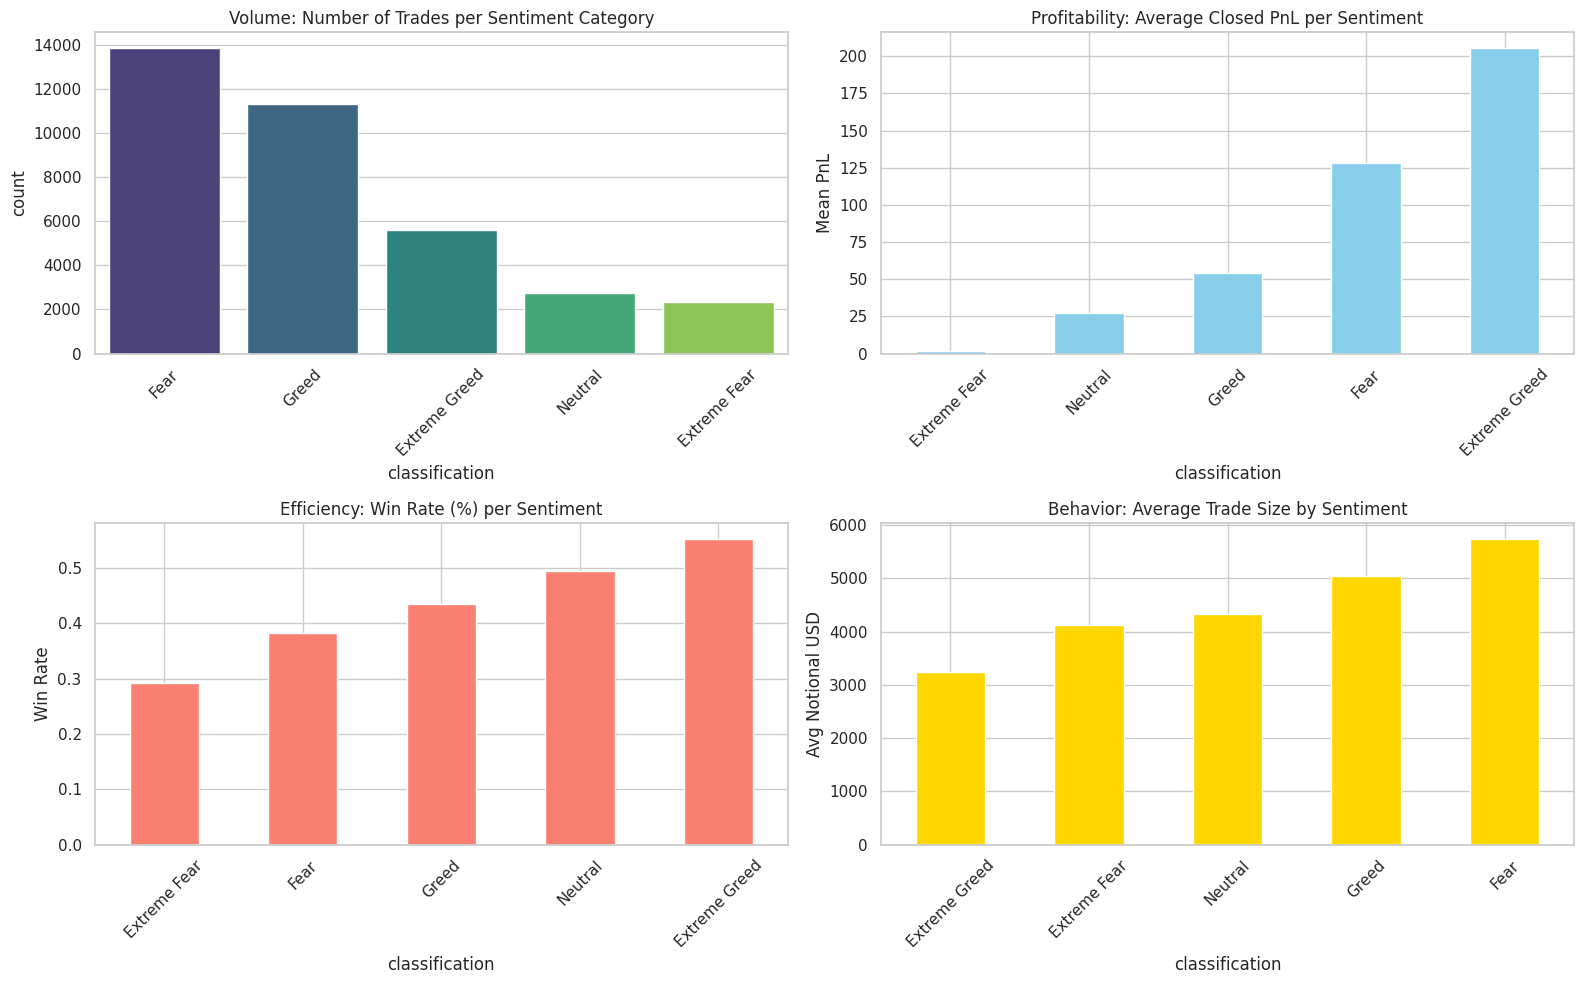


--- Detailed Performance Summary by Sentiment ---


closed_pnl                             win_rate     notional  \
                       avg         total          std       avg          avg   
classification                                                                 
Extreme Fear      1.891632  4.399937e+03    76.727713  0.292777  4118.761904   
Extreme Greed   205.816345  1.156894e+06  1861.557119  0.553282  3242.085054   
Fear            128.287950  1.779226e+06  1342.348497  0.381787  5744.782705   
Greed            53.988003  6.096325e+05  1399.468182  0.435707  5051.878827   
Neutral          27.088803  7.465674e+04   142.945889  0.494920  4332.202775   

               trade_count  
                     count  
classification              
Extreme Fear          2326  
Extreme Greed         5621  
Fear                 13869  
Greed                11292  
Neutral               2756

In [15]:
# 3. Final Analysis: Sentiment vs Performance
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")
plt.figure(figsize=(16, 10))

# Chart 1: Distribution of Trades by Sentiment
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='classification', palette='viridis', order=df['classification'].value_counts().index)
plt.title("Volume: Number of Trades per Sentiment Category")
plt.xticks(rotation=45)

# Chart 2: Average Profit/Loss by Sentiment
plt.subplot(2, 2, 2)
sentiment_pnl = df.groupby('classification')['closed_pnl'].mean().sort_values()
sentiment_pnl.plot(kind='bar', color='skyblue')
plt.title("Profitability: Average Closed PnL per Sentiment")
plt.ylabel("Mean PnL")
plt.xticks(rotation=45)

# Chart 3: Win Rate by Sentiment
plt.subplot(2, 2, 3)
win_rate = df.groupby('classification')['is_profit'].mean().sort_values()
win_rate.plot(kind='bar', color='salmon')
plt.title("Efficiency: Win Rate (%) per Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)

# Chart 4: Average Trade Size (Notional) by Sentiment
plt.subplot(2, 2, 4)
notional_size = df.groupby('classification')['notional'].mean().sort_values()
notional_size.plot(kind='bar', color='gold')
plt.title("Behavior: Average Trade Size by Sentiment")
plt.ylabel("Avg Notional USD")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Final Summary Table
print("\n--- Detailed Performance Summary by Sentiment ---")
summary = df.groupby('classification').agg({
    'closed_pnl': ['mean', 'sum', 'std'],
    'is_profit': 'mean',
    'notional': 'mean',
    'trade_id': 'count'
}).rename(columns={'mean': 'avg', 'sum': 'total', 'is_profit': 'win_rate', 'trade_id': 'trade_count'})

display(summary)

/tmp/ipykernel_16453/4262183249.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='classification', palette='viridis', order=df['classification'].value_counts().index)


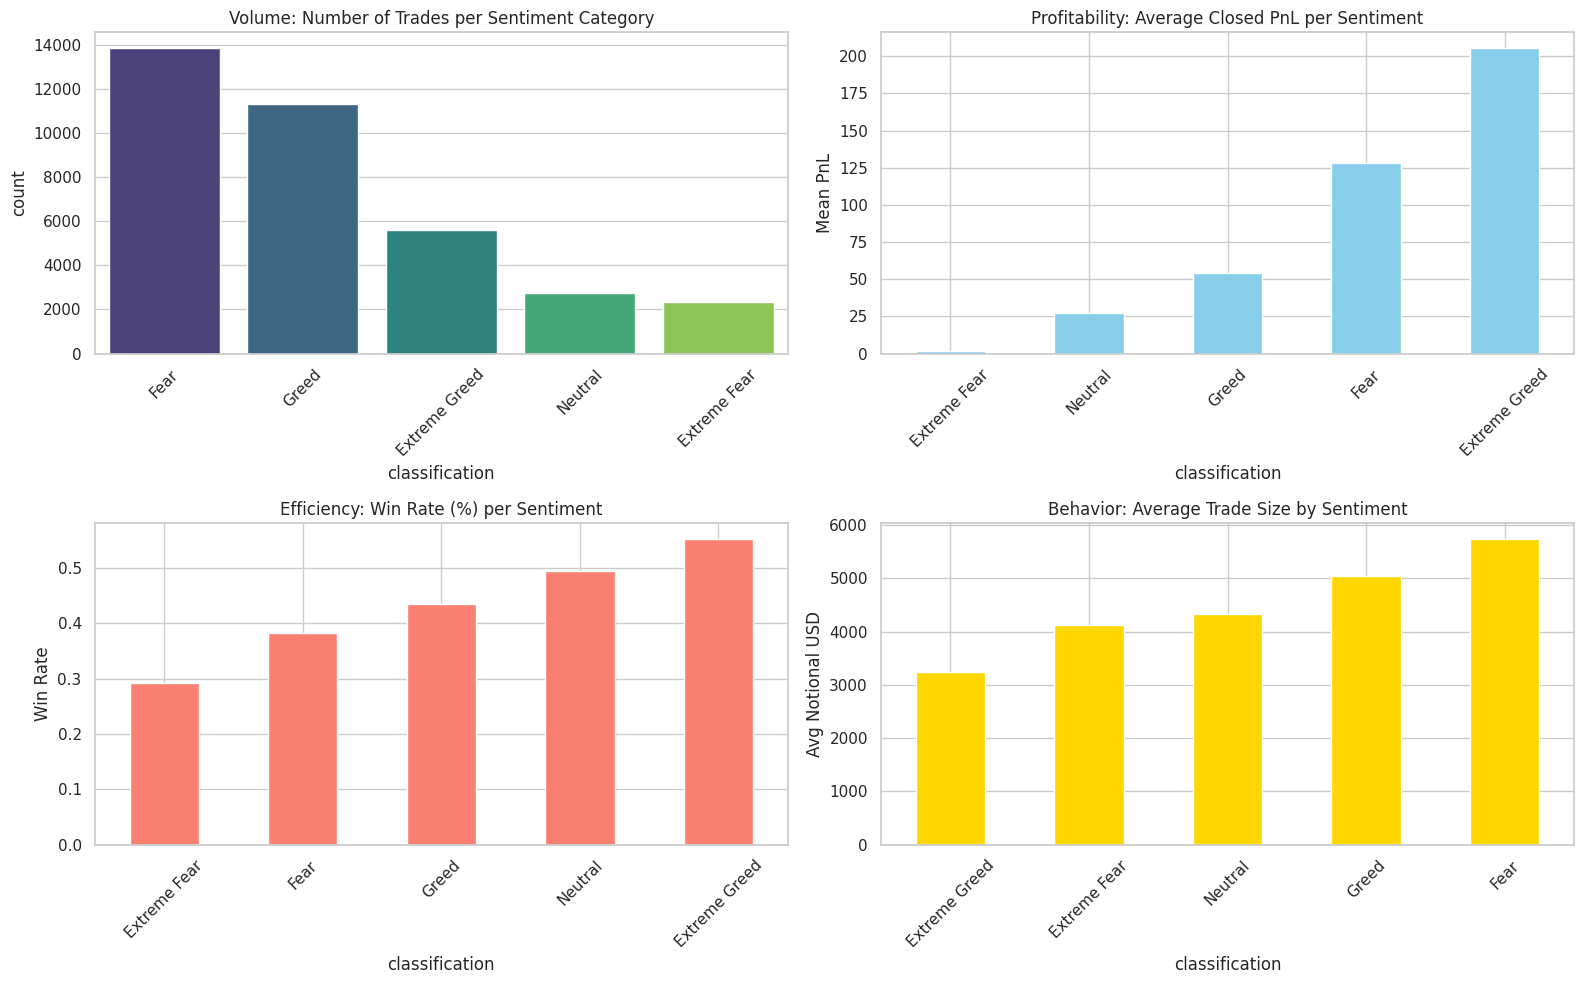


--- Detailed Performance Summary by Sentiment ---


closed_pnl                             win_rate     notional  \
                       avg         total          std       avg          avg   
classification                                                                 
Extreme Fear      1.891632  4.399937e+03    76.727713  0.292777  4118.761904   
Extreme Greed   205.816345  1.156894e+06  1861.557119  0.553282  3242.085054   
Fear            128.287950  1.779226e+06  1342.348497  0.381787  5744.782705   
Greed            53.988003  6.096325e+05  1399.468182  0.435707  5051.878827   
Neutral          27.088803  7.465674e+04   142.945889  0.494920  4332.202775   

               trade_count  
                     count  
classification              
Extreme Fear          2326  
Extreme Greed         5621  
Fear                 13869  
Greed                11292  
Neutral               2756

In [14]:
# 3. Final Analysis: Sentiment vs Performance
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")
plt.figure(figsize=(16, 10))

# Chart 1: Distribution of Trades by Sentiment
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='classification', palette='viridis', order=df['classification'].value_counts().index)
plt.title("Volume: Number of Trades per Sentiment Category")
plt.xticks(rotation=45)

# Chart 2: Average Profit/Loss by Sentiment
plt.subplot(2, 2, 2)
sentiment_pnl = df.groupby('classification')['closed_pnl'].mean().sort_values()
sentiment_pnl.plot(kind='bar', color='skyblue')
plt.title("Profitability: Average Closed PnL per Sentiment")
plt.ylabel("Mean PnL")
plt.xticks(rotation=45)

# Chart 3: Win Rate by Sentiment
plt.subplot(2, 2, 3)
win_rate = df.groupby('classification')['is_profit'].mean().sort_values()
win_rate.plot(kind='bar', color='salmon')
plt.title("Efficiency: Win Rate (%) per Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)

# Chart 4: Average Trade Size (Notional) by Sentiment
plt.subplot(2, 2, 4)
notional_size = df.groupby('classification')['notional'].mean().sort_values()
notional_size.plot(kind='bar', color='gold')
plt.title("Behavior: Average Trade Size by Sentiment")
plt.ylabel("Avg Notional USD")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Final Summary Table
print("\n--- Detailed Performance Summary by Sentiment ---")
summary = df.groupby('classification').agg({
    'closed_pnl': ['mean', 'sum', 'std'],
    'is_profit': 'mean',
    'notional': 'mean',
    'trade_id': 'count'
}).rename(columns={'mean': 'avg', 'sum': 'total', 'is_profit': 'win_rate', 'trade_id': 'trade_count'})

display(summary)

/tmp/ipykernel_16453/1209556014.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='classification', palette='viridis', order=df['classification'].value_counts().index)


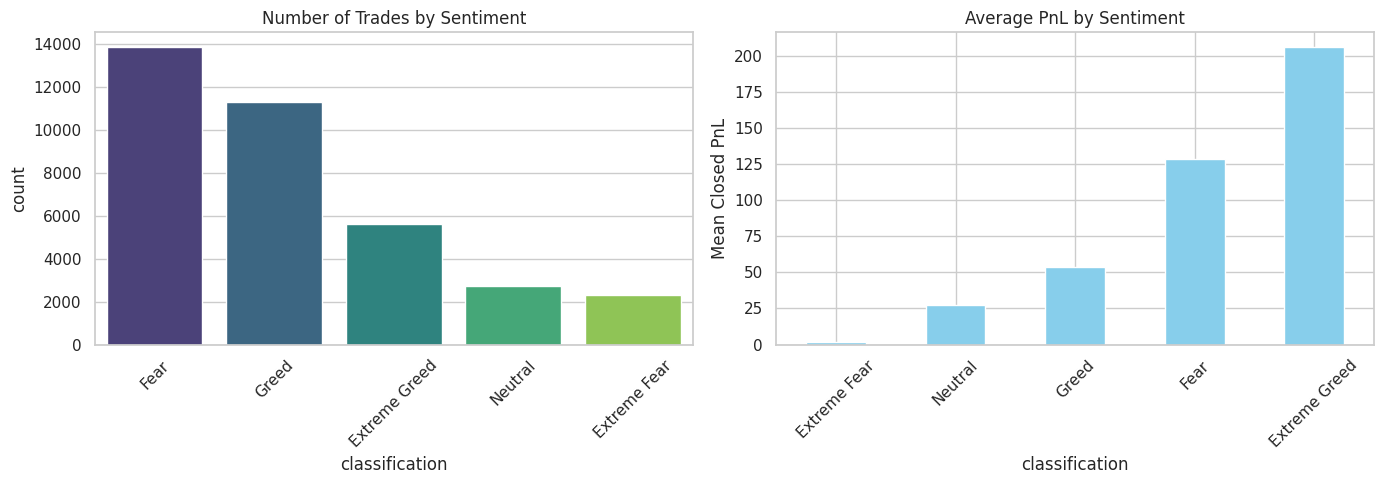

Summary Statistics by Sentiment:


closed_pnl                win_rate     notional
                       avg         total       avg          avg
classification                                                 
Extreme Fear      1.891632  4.399937e+03  0.292777  4118.761904
Extreme Greed   205.816345  1.156894e+06  0.553282  3242.085054
Fear            128.287950  1.779226e+06  0.381787  5744.782705
Greed            53.988003  6.096325e+05  0.435707  5051.878827
Neutral          27.088803  7.465674e+04  0.494920  4332.202775

In [13]:
# 3. Visual Analysis: Sentiment vs Performance
plt.figure(figsize=(14, 5))

# Subplot 1: Trade Counts
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='classification', palette='viridis', order=df['classification'].value_counts().index)
plt.title("Number of Trades by Sentiment")
plt.xticks(rotation=45)

# Subplot 2: Average PnL
plt.subplot(1, 2, 2)
sentiment_pnl = df.groupby('classification')['closed_pnl'].mean().sort_values()
sentiment_pnl.plot(kind='bar', color='skyblue')
plt.title("Average PnL by Sentiment")
plt.ylabel("Mean Closed PnL")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Summary Statistics
print("Summary Statistics by Sentiment:")
display(df.groupby('classification').agg({
    'closed_pnl': ['mean', 'sum'],
    'is_profit': 'mean',
    'notional': 'mean'
}).rename(columns={'mean': 'avg', 'sum': 'total', 'is_profit': 'win_rate'}))